Assignment A

setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, ShuffleSplit
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             mean_squared_error, mean_absolute_error, r2_score)
sns.set_theme(style='whitegrid')
np.random.seed(42)
import sklearn

In [ ]:
from google.colab import files
uploaded= files.upload()

Saving Housing (2).csv to Housing (2).csv


Part 1- Cleaning Data

1. reading the data

In [ ]:
data= pd.read_csv('Housing (2).csv')
dc= data.copy() #dataclean as dc
data.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


2. shape, data types and column names

In [ ]:
print('Shape:', dc.shape)
print('Data Types:', dc.dtypes)
print('Column Names:', dc.columns)

Shape: (545, 13)
Data Types: price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad            object
guestroom           object
basement            object
hotwaterheating     object
airconditioning     object
parking              int64
prefarea            object
furnishingstatus    object
dtype: object
Column Names: Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')


3. Missing or NaN values

In [ ]:
dc.isna().sum() #there are no NaN values

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


4. Duplicate rows

In [ ]:
dc.duplicated().sum() #no duplicated rows

np.int64(0)

5. converting categorical columns

In [ ]:
dc_encoded = pd.get_dummies(dc, columns=['mainroad', 'guestroom', 'basement', 'hotwaterheating','airconditioning', 'prefarea','furnishingstatus'], drop_first=True, dtype=int)
print(dc_encoded)

        price  area  bedrooms  bathrooms  stories  parking  mainroad_yes  \
0    13300000  7420         4          2        3        2             1   
1    12250000  8960         4          4        4        3             1   
2    12250000  9960         3          2        2        2             1   
3    12215000  7500         4          2        2        3             1   
4    11410000  7420         4          1        2        2             1   
..        ...   ...       ...        ...      ...      ...           ...   
540   1820000  3000         2          1        1        2             1   
541   1767150  2400         3          1        1        0             0   
542   1750000  3620         2          1        1        0             1   
543   1750000  2910         3          1        1        0             0   
544   1750000  3850         3          1        2        0             1   

     guestroom_yes  basement_yes  hotwaterheating_yes  airconditioning_yes  \
0        

6. Outliers- IQR method

In [ ]:
cols = ['price', 'area'] #IQR method
Q1 = dc[cols].quantile(0.25)
Q3 = dc[cols].quantile(0.75)
IQR = Q3 - Q1
outlier_mask = (dc[cols] < (Q1 - 1.5 * IQR)) | (dc[cols] > (Q3 + 1.5 * IQR))
outliers_dc = dc[outlier_mask.any(axis=1)]
print(outlier_mask.sum())

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
dc[cols] = dc[cols].clip(lower=lower, upper=upper, axis=1)

price    0
area     0
dtype: int64


Part 2- Linear Regression Model

In [ ]:
# 1.Splitting the data
X = dc_encoded[['area', 'bedrooms', 'bathrooms', 'stories', 'parking',
                'mainroad_yes', 'guestroom_yes', 'basement_yes', 'hotwaterheating_yes',
                'airconditioning_yes', 'prefarea_yes', 'furnishingstatus_semi-furnished',
                'furnishingstatus_unfurnished']]
y = dc_encoded[['price']]
print(X.shape)
print(y.shape)

# 2.training linear regression model
X_tr, X_ts, y_tr, y_ts = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_tr.shape)
print(X_ts.shape)

# 3.making predictions
model = LinearRegression()
model.fit(X_tr, y_tr)
y_pred = model.predict(X_ts)

# 4.evaluating the model
model.score(X_ts, y_ts)
mse = mean_squared_error(y_ts, y_pred)
mae = mean_absolute_error(y_ts, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_ts, y_pred)
print(f"R^2 score is: {r2:.3f}")

cv= ShuffleSplit(n_splits=10, test_size=0.2, random_state=42)
scores = cross_val_score(LinearRegression(), X, y, cv=cv)
print(f"Stable Average Score: {scores.mean():.3f}")


(545, 13)
(545, 1)
(436, 13)
(109, 13)
R^2 score is: 0.680
Stable Average Score: 0.657


R square score- It means 68% of the variation in house Prices can be explained by the given features. This shows that the model understands about two-thirds of why the prices increase or decrease.

5. Visualising the Results

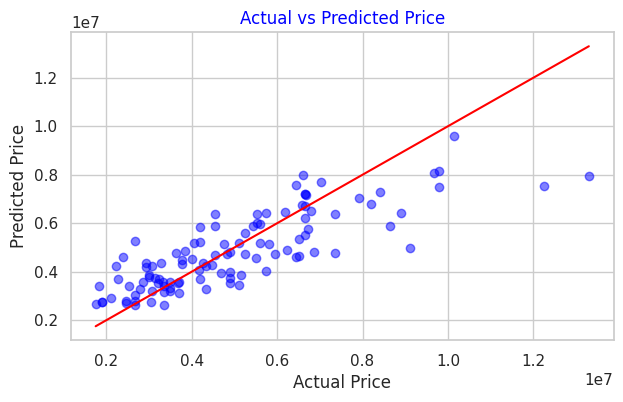

In [ ]:
plt.figure(figsize=(7, 4))
plt.scatter(y_ts, y_pred, alpha=0.5, color='blue', label='Predictions')

max_val = max(max(y_ts.values), max(y_pred))
min_val = min(min(y_ts.values), min(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], color='red', label='Perfect Prediction')

plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Price', color='blue')
plt.grid(True)
plt.show()

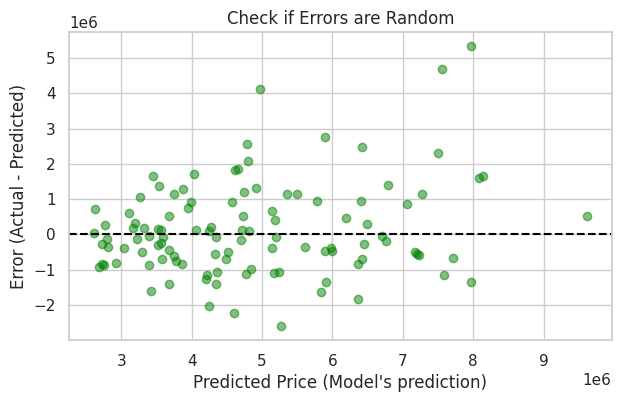

In [ ]:
residual = y_ts - y_pred
plt.figure(figsize=(7, 4))
plt.scatter(y_pred, residual, alpha=0.5, color='green')
plt.axhline(y=0, color='black', linestyle='--')
plt.xlabel('Predicted Price (Model\'s prediction)')
plt.ylabel('Error (Actual - Predicted)')
plt.title('Check if Errors are Random')
plt.show()

6. Inspecting the Coefficients

In [ ]:
coefficients_table = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_.flatten()})
print("Coefficients Table:")
print(coefficients_table)
print(f"intercept: {model.intercept_[0]:.3f}")

#print(dc_encoded['price'].mean())

Coefficients Table:
                            Feature    Coefficient
0                              area     253.474990
1                          bedrooms   80425.444971
2                         bathrooms  978418.072273
3                           stories  404836.217108
4                           parking  174313.007080
5                      mainroad_yes  377681.397738
6                     guestroom_yes  229926.356367
7                      basement_yes  368042.604324
8               hotwaterheating_yes  739166.972835
9               airconditioning_yes  750094.010200
10                     prefarea_yes  596828.350565
11  furnishingstatus_semi-furnished  -81884.263470
12     furnishingstatus_unfurnished -383440.468931
intercept: 320853.536


1. Here, "bathrooms" feature has the largest positive impact on price
For every 1 unit increase in this feature, the predicted price increases by about 9,78,418/- (assuming all other factors stay the same).

2. Yes, this makes real-world sense because a bathroom is one of the most complex parts of a house to build. A bathroom requires specialized plumbing, waterproofing, and expensive fixtures, etc. Because of this high construction cost and the added convenience it provides, the market values an extra bathroom as a major upgrade and is hence very expensive.